Student Name: Li Yuan

Student ID: 21234252

In [ ]:
# necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# upload dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('features_30_sec.csv')

# check dataset
print("dataset (row, column):", df.shape)
print("\nfirst 5 data:")
df.head()

Saving features_30_sec.csv to features_30_sec.csv
dataset (row, column): (1000, 60)

first 5 data:


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
# basic information of dataset
print("\nBasic information of Dataset:")
df.info()

# check if 'label' are evenly distributed
print("\nThe distribution of music classify:")
print(df['label'].value_counts())

# check missing value
print("\nNumber of missing value of each column:")
print(df.isnull().sum())

# check duplicate rows
duplicates = df.duplicated().sum()
print("\nRows of duplicate: ",duplicates)


Basic information of Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64

In [ ]:
# del 'filename' and 'length' which is not a feature
df_cleaned = df.drop(columns=['filename','length'])

# select '_mean' columns and 'tempo' column
select_columns = [col for col in df_cleaned.columns if 'mean' in col]
select_columns = select_columns + ['tempo']

# separate the feature columns（X） and target variable column（Y）
X = df_cleaned[select_columns]
Y = df_cleaned['label']

# feature standardization, mean=0, sd=1
scaler = StandardScaler()      # prepare standardization tool
X_scaled = scaler.fit_transform(X)  # NumPy array
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) # Dataframe

In [ ]:
# divide training dataset and test dataset（stratified sampling）
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42, stratify=Y)

# train the random forest model
rf_model = RandomForestClassifier().fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(f"Training dataset: {X_train.shape}, Test dataset: {X_test.shape}")
print(f"Accuracy rate: {accuracy_score(y_test, y_pred):.1%}")
print(f"Random guessing accuracy: 10% (10 genres)") # random forest model performs 6.5 times better than random gues

Training dataset: (800, 29), Test dataset: (200, 29)
Accuracy rate: 70.0%
Random guessing accuracy: 10% (10 genres)


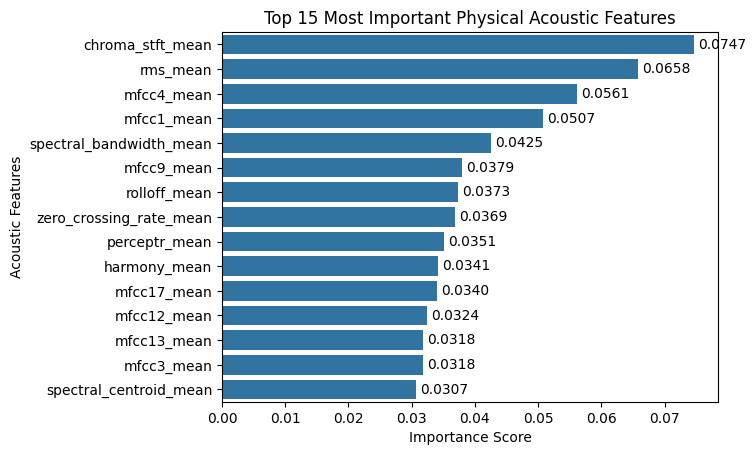

Average feature importance: 0.0345


In [ ]:
# insight1: chroma_stft is the most important feature for distinguishing music genres, with rms and mfcc4 also playing key roles
# observation: importance of features in determining music genres

# get feature importance
# parameter1: random Forest model's built-in method, automatically calculates importance scores for each feature
# parameter2: use training data to analysis the importance of teature
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.nlargest(15) # pandas_series method that returns the 15 largest values in the Series

# plot horizontal bar chart of Top 15 most important features
barchart = sns.barplot(x=feature_importances.values, y=feature_importances.index)
# Optimize chart
barchart.bar_label(barchart.containers[0], fmt="%.4f", padding=3) # add value labels to each bar
plt.title("Top 15 Most Important Physical Acoustic Features")
plt.xlabel('Importance Score')
plt.ylabel('Acoustic Features')
plt.show()

# average importance value of each feature (29 features total)
print(f"Average feature importance: {1.0/len(X_train.columns):.4f}")
# The first two features are approximately 2 times the average value, significantly higher than other features

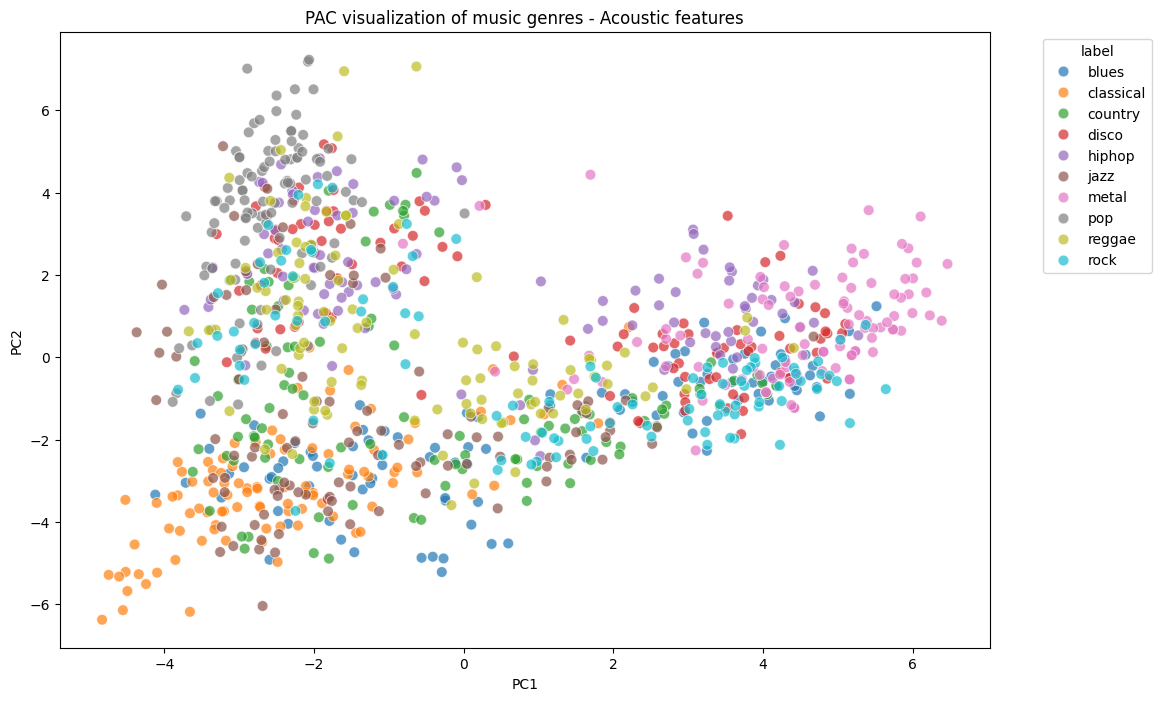

PC1 explained the variance of 29.18%
PC2 explained the variance of 22.94%
The first two principal components together accounted the variance of 52.12%


In [ ]:
# insight2：natural clustering of genres reveals unique acoustic features
# observation: Clustering phenomenon of music genres in the condense dimensional space

# perform PCA and condense to 2 dimensions
pca = PCA(n_components=2)  # create pca obeject
X_pca = pca.fit_transform(X_scaled) # analyze overall trend using entire dataset
# create dataframe of PCA results
pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1]})

# plot scatter chart
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=Y, alpha=0.7, s=60)
# optimize chart
plt.title('PAC visualization of music genres - Acoustic features')
plt.legend(bbox_to_anchor=(1.05, 1), title='label')
plt.show()

# explain the contribution rate of PCA
print(f"PC1 explained the variance of {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 explained the variance of {pca.explained_variance_ratio_[1]:.2%}")
print(f"The first two principal components together accounted the variance of {sum(pca.explained_variance_ratio_[:2]):.2%}")

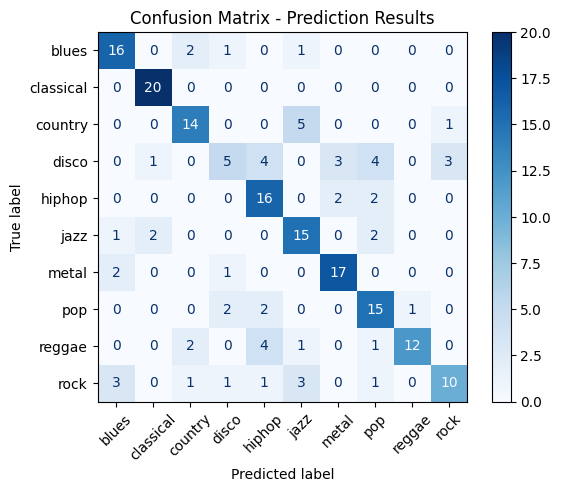

The most common errors in number: 5


In [ ]:
# insight3：identifying the most acoustically similar or unique genres
# observation: Music genres that are easily confused have relatively high acoustic similarity

# calculate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
unique_Y = sorted(Y.unique())  # obtain all non-duplicate values
ConfusionMatrixDisplay(cm, display_labels=unique_Y).plot(cmap='Blues')

# optimize chart
plt.title('Confusion Matrix - Prediction Results')
plt.xticks(rotation=45)
plt.show()

# diagonal data: number of samples correctly classified by the model.
print(f"The most common errors in number: {cm[cm != np.diag(cm)].max()}")

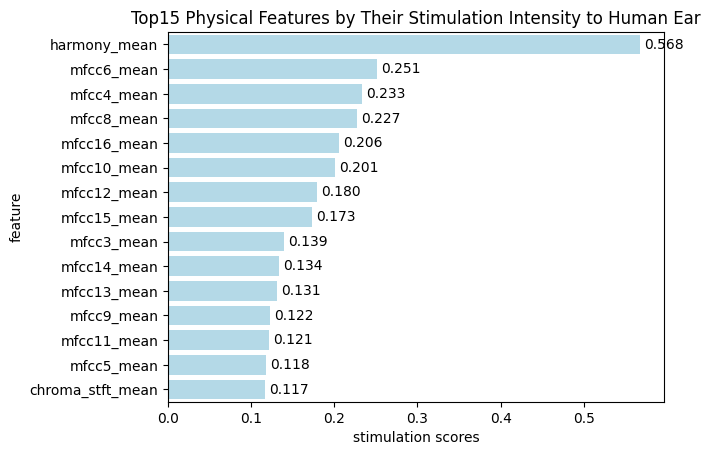

In [ ]:
# insight4: harmony can elicit strong reactions from the human ear
# observation: some sound features stimulate the human ear significantly than others

X_perceptr_scaled = X_scaled.drop(columns=['perceptr_mean'])
y_perceptr = X_scaled['perceptr_mean']

# calculate abs(correlation coefficient, r) of each physical feature with stimulation level
stimulation_scores = {feature: abs(np.corrcoef(X_perceptr_scaled[feature], y_perceptr)[0, 1])
           for feature in X_perceptr_scaled.columns}

# convert to a DataFrame (firstly convert dict to a list containing tuples)
stimulation_scores = pd.DataFrame(stimulation_scores.items(), columns=['feature', 'stimulation scores'])
stimulation_scores = stimulation_scores.sort_values('stimulation scores', ascending=False).head(15)

# plot horizontal bar chart ranking the top15 stimulation intencity
barchart = sns.barplot(data=stimulation_scores, y='feature', x='stimulation scores', color='skyblue', alpha=0.7)
barchart.bar_label(barchart.containers[0], fmt='%.3f', padding=3)  # # add value labels to each bar
plt.title('Top15 Physical Features by Their Stimulation Intensity to Human Ear')
plt.show()

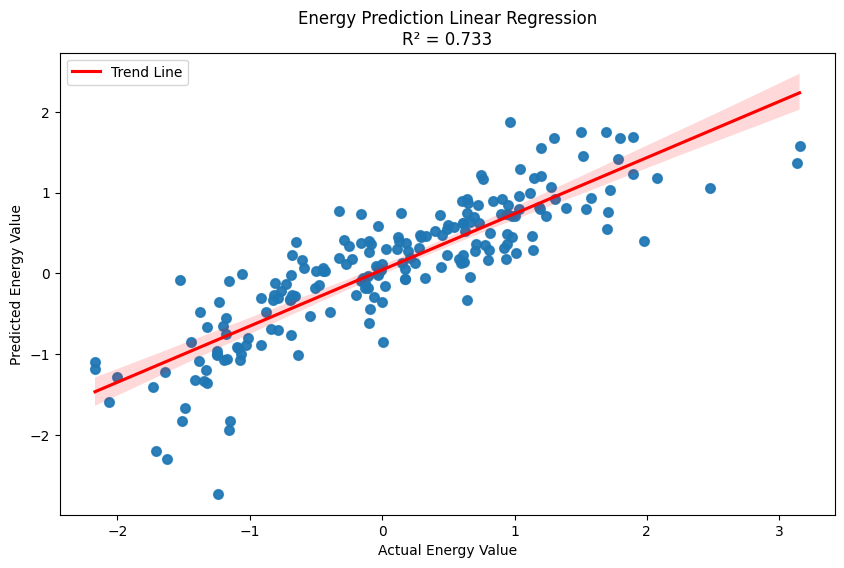

                   feature  coefficient
1   spectral_centroid_mean     2.087209
3             rolloff_mean    -1.250110
8               mfcc2_mean     0.430250
4  zero_crossing_rate_mean    -0.332514
7               mfcc1_mean     0.219356


In [ ]:
# insight5: energy level prediction
# observation: the influence of different acoustic features on the energy

# training dataset
X_energy_scaled = X_scaled.drop(columns=['chroma_stft_mean'])
y_energy =  X_scaled['chroma_stft_mean']
X_energy_train, X_energy_test, y_energy_train, y_energy_test = train_test_split(X_energy_scaled, y_energy, test_size=0.2, random_state=42)

# build linear regression prediction model
energy_model = LinearRegression().fit(X_energy_train, y_energy_train)
y_energy_pred = energy_model.predict(X_energy_test)
energy_score = energy_model.score(X_energy_test, y_energy_test) # R²

# Plot a linear regression chart
plt.figure(figsize=(10, 6))
plt.scatter(y_energy_test, y_energy_pred, alpha=0.7, s=50)
# optimize chart
sns.regplot(x=y_energy_test, y=y_energy_pred, line_kws={'color':'red', 'label':'Trend Line'})
plt.xlabel('Actual Energy Value')
plt.ylabel('Predicted Energy Value')
plt.title(f'Energy Prediction Linear Regression\nR² = {energy_score:.3f}')
plt.legend()
plt.show()

# key features & coefficient(contribution value/degree of importance)
energy_coef = pd.DataFrame({'feature': X_energy_scaled.columns, 'coefficient': energy_model.coef_}
        ).sort_values('coefficient', key=abs, ascending=False)
print(energy_coef.head(5))